In [1]:
pip install opencv-contrib-python scikit-image pywavelets matplotlib pandas scikit-learn

In [2]:
import cv2
import os
import numpy as np
import pywt
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
!ls "/content/drive/MyDrive/DIP Dataset 4 AT and T Dataset"

README	s11  s14  s17  s2   s22  s25  s28  s30	s33  s36  s39  s5  s8
s1	s12  s15  s18  s20  s23  s26  s29  s31	s34  s37  s4   s6  s9
s10	s13  s16  s19  s21  s24  s27  s3   s32	s35  s38  s40  s7


In [7]:
dataset_path = "/content/drive/MyDrive/DIP Dataset 4 AT and T Dataset"

In [9]:
import cv2
import os
import numpy as np

dataset_path = "/content/drive/MyDrive/DIP Dataset 4 AT and T Dataset"

images = []
labels = []

for person in os.listdir(dataset_path):

    person_path = os.path.join(dataset_path, person)

    if not os.path.isdir(person_path):
        continue

    # label comes from folder name s1, s2, s3...
    label = int(person.replace("s",""))

    for img_name in os.listdir(person_path):

        img_path = os.path.join(person_path, img_name)

        img = cv2.imread(img_path)

        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        gray = cv2.resize(gray, (100,100))

        images.append(gray)
        labels.append(label)

images = np.array(images)
labels = np.array(labels)

print("Total images loaded:", len(images))
print("Total labels:", len(labels))

Total images loaded: 400
Total labels: 400


In [10]:
X_train,X_test,y_train,y_test = train_test_split(
    images,labels,test_size=0.3,random_state=42)

In [11]:
def train_predict(train_imgs,test_imgs):

    model = cv2.face.LBPHFaceRecognizer_create()

    model.train(train_imgs,y_train)

    predictions = []

    for img in test_imgs:

        label,conf = model.predict(img)
        predictions.append(label)

    return predictions

In [12]:
def compute_metrics(preds):

    acc = accuracy_score(y_test,preds)*100
    prec = precision_score(y_test,preds,average='macro')*100
    rec = recall_score(y_test,preds,average='macro')*100
    f1 = f1_score(y_test,preds,average='macro')*100

    return acc,prec,rec,f1

In [13]:
def image_quality(original, processed):

    original = original.astype(np.uint8)
    processed = processed.astype(np.uint8)

    p = psnr(original, processed, data_range=255)

    s, _ = ssim(original, processed, full=True, data_range=255)

    return p, s

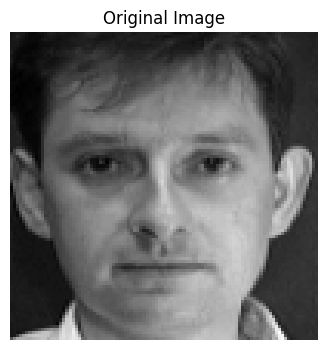

In [35]:
import matplotlib.pyplot as plt

sample = X_test[0]

plt.figure(figsize=(4,4))
plt.imshow(sample, cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()

In [14]:
def median_filter(img):
    return cv2.medianBlur(img,3)

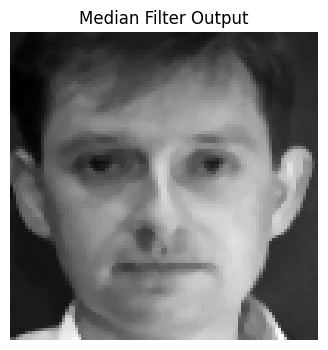

In [36]:
median_img = median_filter(sample)

plt.figure(figsize=(4,4))
plt.imshow(median_img, cmap='gray')
plt.title("Median Filter Output")
plt.axis("off")
plt.show()

In [15]:
def gray_normalization(img):

    norm = cv2.normalize(img,None,0,255,cv2.NORM_MINMAX)

    return norm

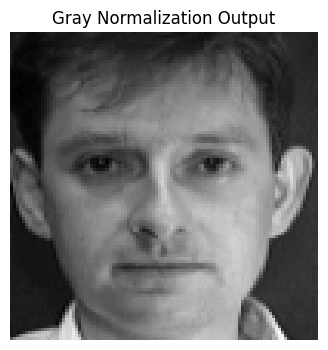

In [37]:
graynorm_img = gray_normalization(sample)

plt.figure(figsize=(4,4))
plt.imshow(graynorm_img, cmap='gray')
plt.title("Gray Normalization Output")
plt.axis("off")
plt.show()

In [16]:
def geometric_norm(img):

    rows,cols = img.shape

    M = cv2.getRotationMatrix2D((cols/2,rows/2),5,1)

    return cv2.warpAffine(img,M,(cols,rows))

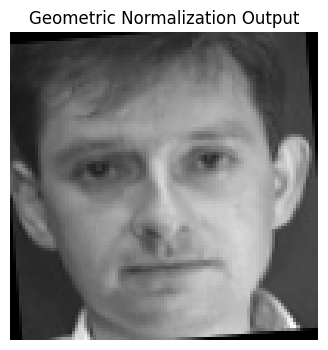

In [38]:
geom_img = geometric_norm(sample)

plt.figure(figsize=(4,4))
plt.imshow(geom_img, cmap='gray')
plt.title("Geometric Normalization Output")
plt.axis("off")
plt.show()

In [17]:
def wavelet_transform(img):

    coeffs = pywt.dwt2(img,'haar')

    LL,(LH,HL,HH) = coeffs

    return cv2.resize(LL,(100,100))

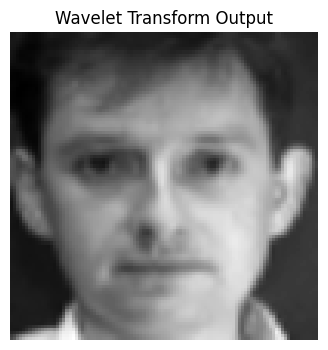

In [39]:
wavelet_img = wavelet_transform(sample)

plt.figure(figsize=(4,4))
plt.imshow(wavelet_img, cmap='gray')
plt.title("Wavelet Transform Output")
plt.axis("off")
plt.show()

In [18]:
def hist_eq(img):

    return cv2.equalizeHist(img)

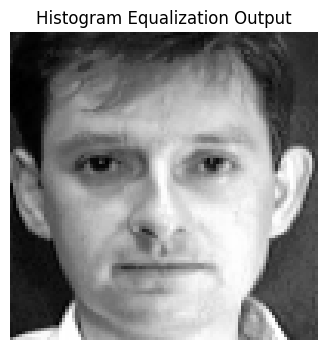

In [40]:
hist_img = hist_eq(sample)

plt.figure(figsize=(4,4))
plt.imshow(hist_img, cmap='gray')
plt.title("Histogram Equalization Output")
plt.axis("off")
plt.show()

In [19]:
def gaussian_filter(img):

    return cv2.GaussianBlur(img,(3,3),0)

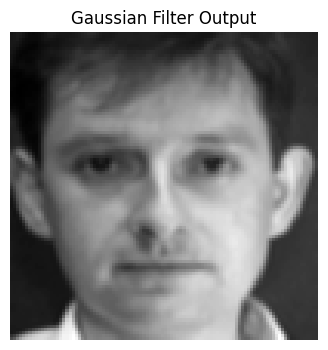

In [41]:
gauss_img = gaussian_filter(sample)

plt.figure(figsize=(4,4))
plt.imshow(gauss_img, cmap='gray')
plt.title("Gaussian Filter Output")
plt.axis("off")
plt.show()

In [20]:
def bilateral_filter(img):

    return cv2.bilateralFilter(img,9,75,75)

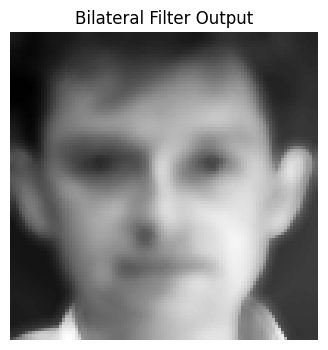

In [42]:
bilateral_img = bilateral_filter(sample)

plt.figure(figsize=(4,4))
plt.imshow(bilateral_img, cmap='gray')
plt.title("Bilateral Filter Output")
plt.axis("off")
plt.show()

In [21]:
def sharpen(img):

    kernel = np.array([[0,-1,0],
                       [-1,5,-1],
                       [0,-1,0]])

    return cv2.filter2D(img,-1,kernel)

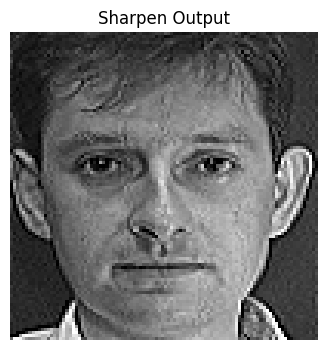

In [43]:
sharp_img = sharpen(sample)

plt.figure(figsize=(4,4))
plt.imshow(sharp_img, cmap='gray')
plt.title("Sharpen Output")
plt.axis("off")
plt.show()

In [22]:
methods = {
"Original":lambda x:x,
"Median":median_filter,
"GrayNorm":gray_normalization,
"Geometric":geometric_norm,
"Wavelet":wavelet_transform,
"Histogram":hist_eq,
"Gaussian":gaussian_filter,
"Bilateral":bilateral_filter,
"Sharpen":sharpen
}

results=[]
accuracies=[]

In [23]:
for name, func in methods.items():

    # Apply preprocessing
    X_train_proc = np.array([func(img) for img in X_train])
    X_test_proc = np.array([func(img) for img in X_test])

    # Train model and predict
    preds = train_predict(X_train_proc, X_test_proc)

    # Recognition metrics
    acc, prec, rec, f1 = compute_metrics(preds)

    # ----- IMAGE QUALITY METRICS -----
    psnr_values = []
    ssim_values = []

    for i in range(len(X_test)):

        p, s = image_quality(X_test[i], X_test_proc[i])

        psnr_values.append(p)
        ssim_values.append(s)

    avg_psnr = np.mean(psnr_values)
    avg_ssim = np.mean(ssim_values)

    # Store results
    results.append([name, acc, prec, rec, f1, avg_psnr, avg_ssim])

    accuracies.append(acc)

    print(name, "Done")

/usr/local/lib/python3.12/dist-packages/skimage/metrics/simple_metrics.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)


Original Done
Median Done
GrayNorm Done
Geometric Done


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Wavelet Done
Histogram Done
Gaussian Done
Bilateral Done
Sharpen Done


In [27]:
import pandas as pd

columns = ["Method","Accuracy","Precision","Recall","F1 Score","PSNR","SSIM"]

df = pd.DataFrame(results, columns=columns)

print(df)

      Method   Accuracy  Precision     Recall   F1 Score       PSNR      SSIM
0   Original  95.833333  97.069597  97.985348  96.788767        inf  1.000000
1     Median  95.833333  96.428571  97.985348  96.532357  35.138173  0.960891
2   GrayNorm  95.833333  97.069597  97.985348  96.788767  22.470873  0.961955
3  Geometric  95.833333  96.428571  97.985348  96.739927  19.835829  0.645093
4    Wavelet  93.333333  92.833333  93.720238  92.588023   8.896202  0.330046
5  Histogram  95.833333  97.069597  97.985348  96.788767  17.642957  0.825900
6   Gaussian  95.833333  97.069597  97.985348  96.788767  35.002832  0.966300
7  Bilateral  95.833333  96.688034  97.939560  96.855644  27.913229  0.812608
8    Sharpen  93.333333  94.786325  96.611722  94.428164  22.860421  0.761938


In [28]:
display(df)

,Method,Accuracy,Precision,Recall,F1 Score,PSNR,SSIM
0,Original,95.833333,97.069597,97.985348,96.788767,inf,1.000000
1,Median,95.833333,96.428571,97.985348,96.532357,35.138173,0.960891
2,GrayNorm,95.833333,97.069597,97.985348,96.788767,22.470873,0.961955
3,Geometric,95.833333,96.428571,97.985348,96.739927,19.835829,0.645093
4,Wavelet,93.333333,92.833333,93.720238,92.588023,8.896202,0.330046
5,Histogram,95.833333,97.069597,97.985348,96.788767,17.642957,0.825900
6,Gaussian,95.833333,97.069597,97.985348,96.788767,35.002832,0.966300
7,Bilateral,95.833333,96.688034,97.939560,96.855644,27.913229,0.812608
8,Sharpen,93.333333,94.786325,96.611722,94.428164,22.860421,0.761938


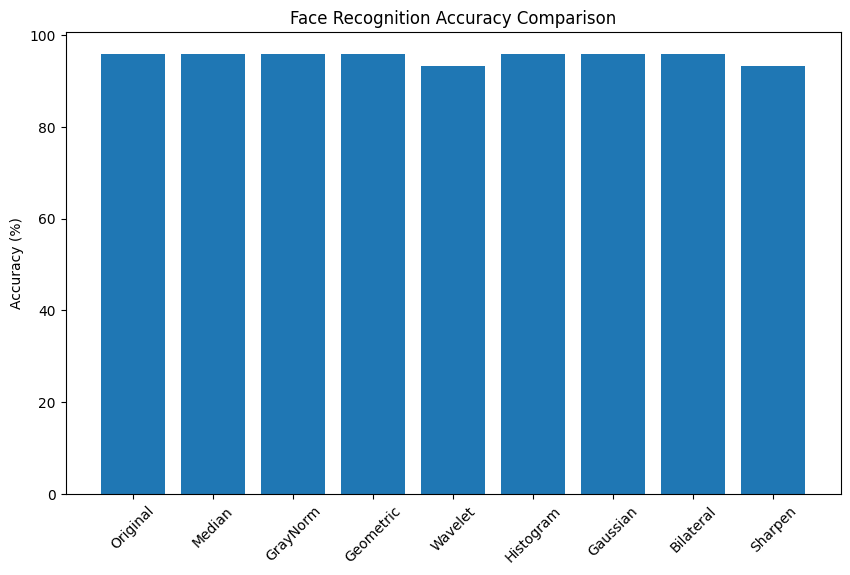

In [29]:
plt.figure(figsize=(10,6))

plt.bar(methods.keys(),accuracies)

plt.xticks(rotation=45)

plt.ylabel("Accuracy (%)")

plt.title("Face Recognition Accuracy Comparison")

plt.show()

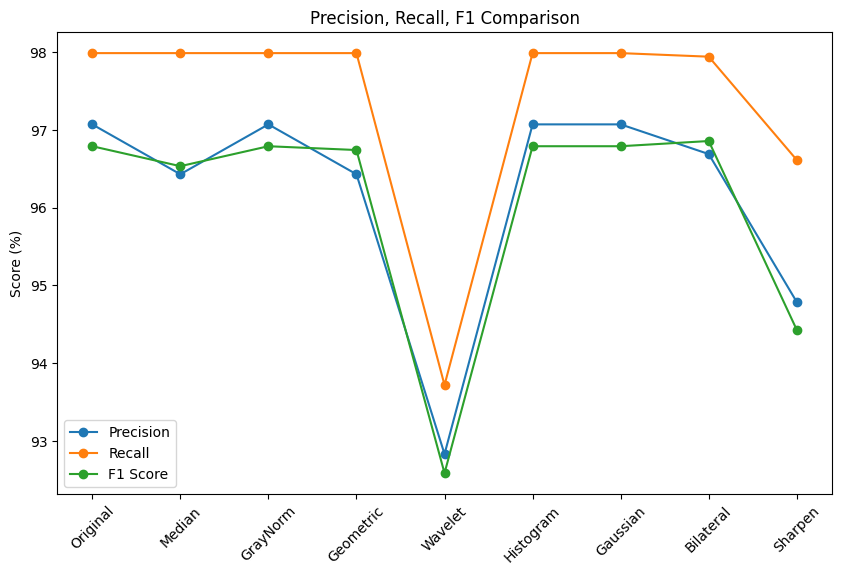

In [30]:
plt.figure(figsize=(10,6))

plt.plot(df["Method"], df["Precision"], marker='o', label="Precision")
plt.plot(df["Method"], df["Recall"], marker='o', label="Recall")
plt.plot(df["Method"], df["F1 Score"], marker='o', label="F1 Score")

plt.xticks(rotation=45)

plt.ylabel("Score (%)")
plt.title("Precision, Recall, F1 Comparison")

plt.legend()

plt.show()

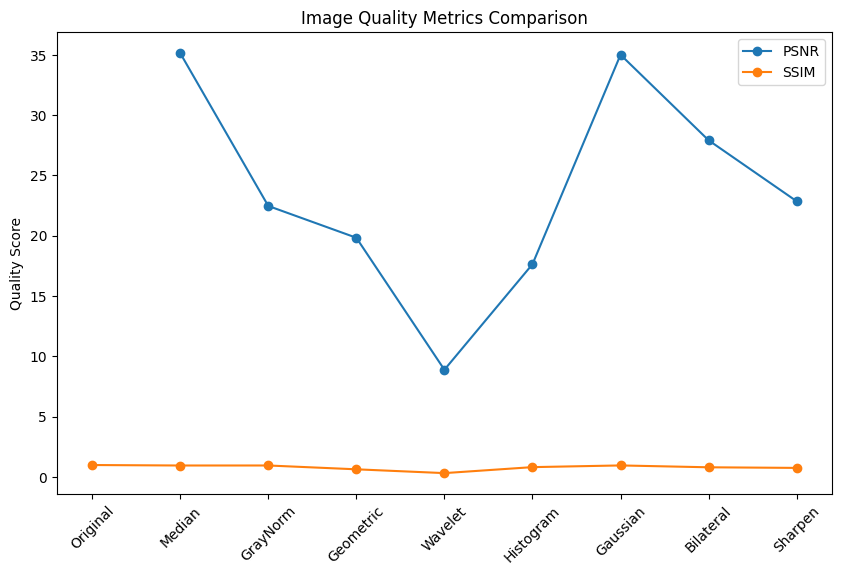

In [31]:
plt.figure(figsize=(10,6))

plt.plot(df["Method"], df["PSNR"], marker='o', label="PSNR")
plt.plot(df["Method"], df["SSIM"], marker='o', label="SSIM")

plt.xticks(rotation=45)

plt.ylabel("Quality Score")
plt.title("Image Quality Metrics Comparison")

plt.legend()

plt.show()

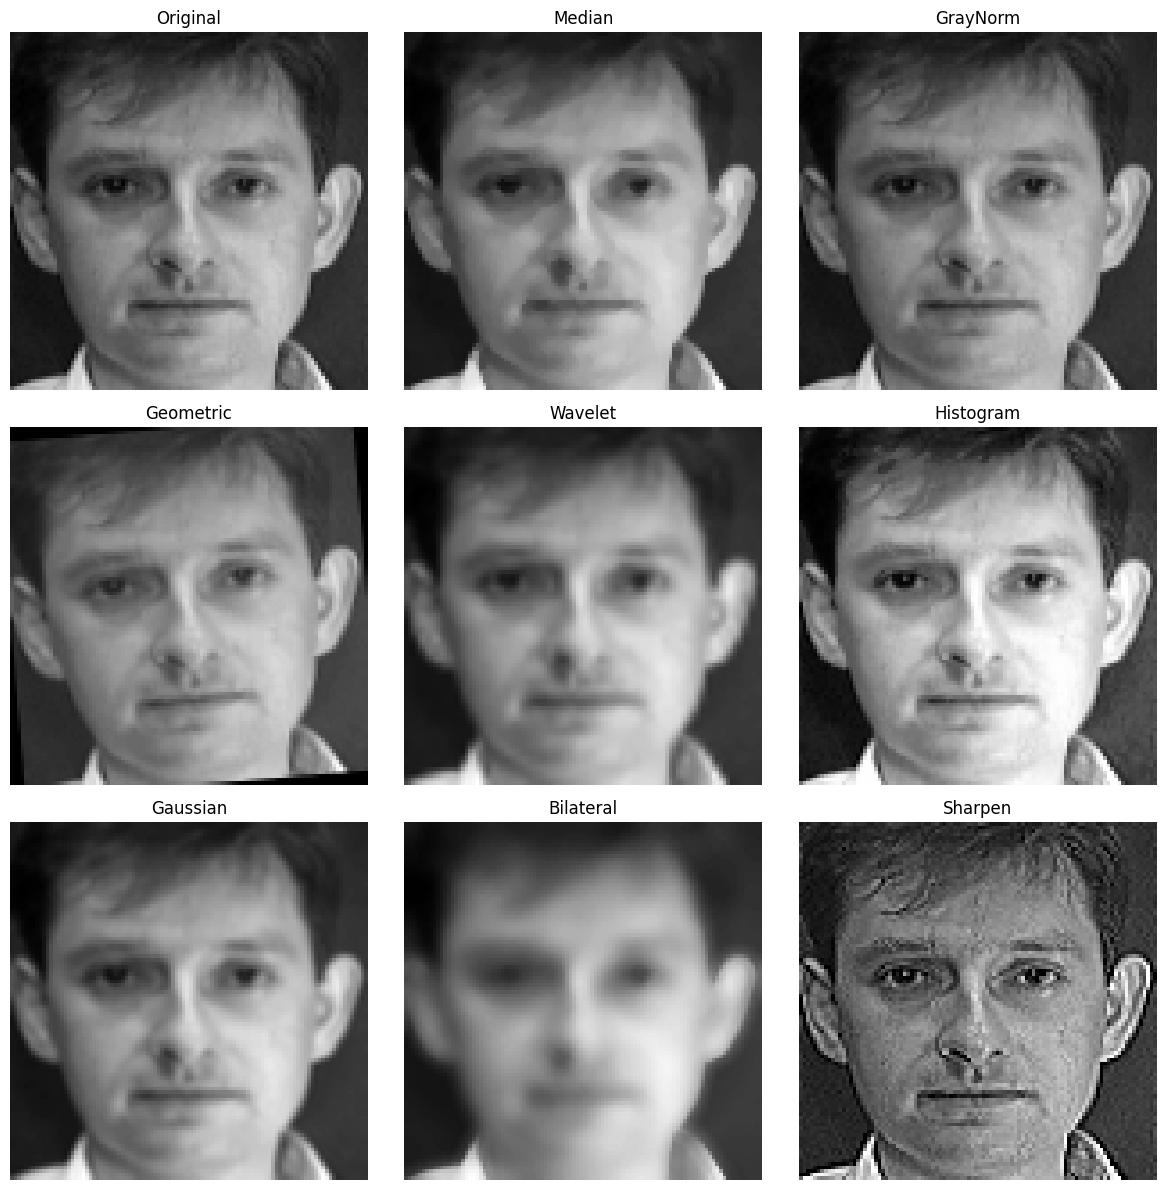

In [32]:
import matplotlib.pyplot as plt

sample = X_test[0]

plt.figure(figsize=(12,12))

# 1 Original
plt.subplot(3,3,1)
plt.imshow(sample, cmap='gray')
plt.title("Original")
plt.axis("off")

# 2 Median
plt.subplot(3,3,2)
plt.imshow(median_filter(sample), cmap='gray')
plt.title("Median")
plt.axis("off")

# 3 Gray Normalization
plt.subplot(3,3,3)
plt.imshow(gray_normalization(sample), cmap='gray')
plt.title("GrayNorm")
plt.axis("off")

# 4 Geometric
plt.subplot(3,3,4)
plt.imshow(geometric_norm(sample), cmap='gray')
plt.title("Geometric")
plt.axis("off")

# 5 Wavelet
plt.subplot(3,3,5)
plt.imshow(wavelet_transform(sample), cmap='gray')
plt.title("Wavelet")
plt.axis("off")

# 6 Histogram Equalization
plt.subplot(3,3,6)
plt.imshow(hist_eq(sample), cmap='gray')
plt.title("Histogram")
plt.axis("off")

# 7 Gaussian
plt.subplot(3,3,7)
plt.imshow(gaussian_filter(sample), cmap='gray')
plt.title("Gaussian")
plt.axis("off")

# 8 Bilateral
plt.subplot(3,3,8)
plt.imshow(bilateral_filter(sample), cmap='gray')
plt.title("Bilateral")
plt.axis("off")

# 9 Sharpen
plt.subplot(3,3,9)
plt.imshow(sharpen(sample), cmap='gray')
plt.title("Sharpen")
plt.axis("off")

plt.tight_layout()
plt.show()